# Diabetes Prediction: Hybrid ML Model (SVD + SVM)

## 1. Introduction
This project applies a Hybrid Machine Learning approach to predict the onset of diabetes based on diagnostic measures. We utilize a pipeline combining **Singular Value Decomposition (SVD)** for dimensionality reduction and **Support Vector Machine (SVM)** for classification.

The dataset is the Pima Indians Diabetes Database. The objective is to predict whether a patient has diabetes (Outcome=1) or not (Outcome=0).

We will compare:
1.  **Base Model**: SVD + SVM (Default parameters)
2.  **Optimized Model**: SVD + SVM (GridSearch tuned)
3.  **Comparison Models**: Logistic Regression and Decision Tree.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set plot style
sns.set(style="whitegrid")

In [2]:
# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
    
df = pd.read_csv(url, header=None, names=[
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
])

# Display first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Methodology
### Preprocessing
- **Feature Scaling**: All features are numerical (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`). We will standardize them using `StandardScaler`.
- **Train-Test Split**: 80-20 split.

In [3]:
# Define features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (614, 8)
Testing set shape: (154, 8)


### Base Model: SVD -> SVM
We define a pipeline that consists of:
1. **Scaler**: `StandardScaler` for all features.
2. **TruncatedSVD**: Reduces dimensionality. We'll start with `n_components=5`.
3. **SVM Classifier**: Uses the RBF kernel.

In [4]:
# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svd', TruncatedSVD(n_components=5, random_state=42)),
    ('svm', SVC(kernel='rbf', random_state=42))
])

# Train the base model
pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pipeline.predict(X_test)
base_accuracy = accuracy_score(y_test, y_pred)

print(f"Base Model Accuracy: {base_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Base Model Accuracy: 0.7208

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.85      0.80        99
           1       0.64      0.49      0.56        55

    accuracy                           0.72       154
   macro avg       0.70      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



## 3. Optimization
We perform Grid Search to tune `svd__n_components`, `svm__C`, and `svm__gamma`.

In [5]:
# Define parameter grid
param_grid = {
    'svd__n_components': [2, 3, 4, 5, 6, 7],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'svd__n_components': 6, 'svm__C': 1, 'svm__gamma': 0.01}
Best Cross-Validation Accuracy: 0.7671


## 4. Results & Conclusion
Evaluating the optimized model.

Optimized Model Accuracy: 0.7922
Improvement: 0.0714

Optimized Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85        99
           1       0.76      0.62      0.68        55

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



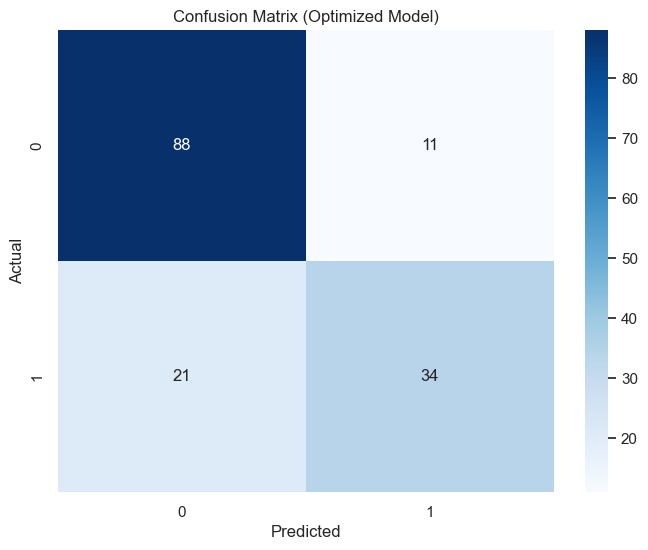

In [6]:
# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
opt_accuracy = accuracy_score(y_test, y_pred_opt)

print(f"Optimized Model Accuracy: {opt_accuracy:.4f}")
print(f"Improvement: {opt_accuracy - base_accuracy:.4f}")

print("\nOptimized Classification Report:\n")
print(classification_report(y_test, y_pred_opt))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Comparison Models
Comparing with Logistic Regression and Decision Tree.

In [7]:
# --- Logistic Regression ---
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# --- Decision Tree ---
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Logistic Regression Accuracy: 0.7532
Decision Tree Accuracy: 0.7468


## 6. Partial Differentiation Model (Gradient Boosting)
We implement **Gradient Boosting**, an ensemble technique that builds models sequentially. It uses **Gradient Descent** (a partial differentiation method) to minimize the loss function (e.g., deviance) by adding weak learners that correct the errors of previous models. This explicitly leverages partial differentiation to optimize the model.

In [8]:
# --- Gradient Boosting (Partial Differentiation Model) ---
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7403

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



## 7. Final Comparison
Summary of all models, including the Partial Differentiation Model.

                 Model  Accuracy
1    Optimized SVD+SVM  0.792208
2  Logistic Regression  0.753247
3        Decision Tree  0.746753
4    Gradient Boosting  0.740260
0         Base SVD+SVM  0.720779


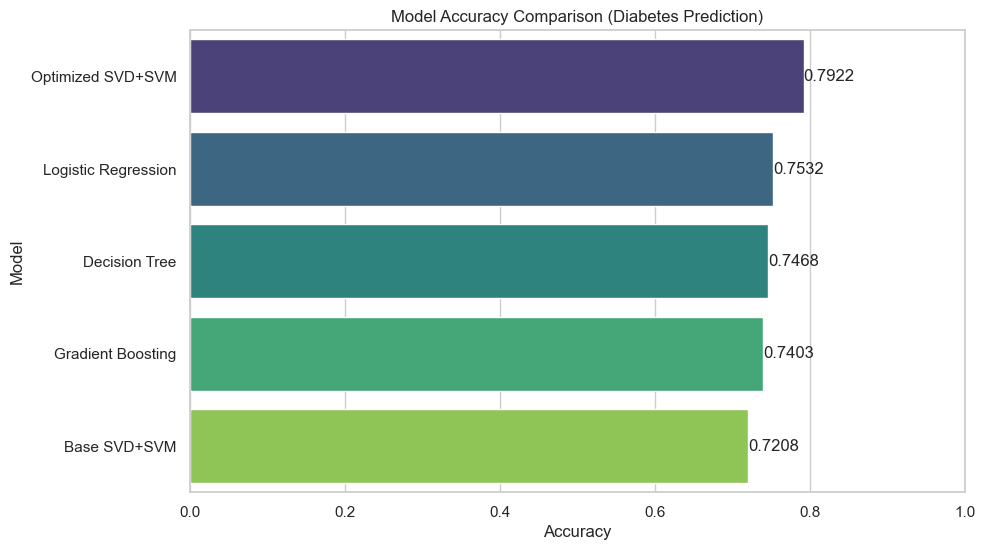

In [9]:
# Create a DataFrame for comparison
results_df = pd.DataFrame({
    'Model': ['Base SVD+SVM', 'Optimized SVD+SVM', 'Logistic Regression', 'Decision Tree', 'Gradient Boosting'],
    'Accuracy': [base_accuracy, opt_accuracy, lr_accuracy, dt_accuracy, gb_accuracy]
})

# Sort by accuracy
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', hue='Model', data=results_df, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison (Diabetes Prediction)')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1.0)
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value, index, f'{value:.4f}', va='center')
plt.show()